In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
over_200_activities = pd.read_csv("../output/testgfp1_activity_SK_over200reads.csv")
over_200_activities

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176208,0.134508,0.119441,0.118305,0.124244,0.153708,0.121450,0.052136,1106.580090
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000335,0.031946,0.079672,0.225509,0.478372,0.169164,0.014405,1406.760337
2,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246809,0.350404,0.222146,0.179075,0.000638,0.000341,0.000181,0.000405,283.106629
3,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,0.000296,0.000377,0.001111,0.011348,0.038243,0.156882,0.485088,0.306655,3456.398406
4,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,0.241711,0.129947,0.115391,0.102470,0.070759,0.095096,0.155612,0.089013,1307.599766
...,...,...,...,...,...,...,...,...,...,...
6891,TTTGTTGCTTCTCAATTGATGTCTCAAGAAGATGGTGTTTCTGGAT...,0.656599,0.213327,0.061126,0.027296,0.000259,0.000083,0.021688,0.019622,361.103214
6892,AAGACTACTAAAGATGGTGATAATTTGCAAGATCAAGATCAGAAAT...,0.000000,0.011386,0.739734,0.038387,0.069597,0.074348,0.044482,0.022066,677.079090
6893,ATGAAGATCTTGCCAGTTGGTTCTAGATTCTGTCCAACTGATTTGG...,0.000000,0.003562,0.000000,0.000783,0.123386,0.264223,0.519165,0.088882,2368.066214
6894,GAAATGTTGGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,0.000000,0.005198,0.004615,0.009143,0.010590,0.025455,0.189523,0.755476,5343.920016


In [4]:
over_200_reads_series = pd.read_csv("../output/testgfp1_readsseries_SK_over60reads.csv")
display(over_200_reads_series)
min(over_200_reads_series['0'])

,AD,0
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,608.0
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,44353.0
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,68.0
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,5086.0
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,170.0
...,...,...
10335,TTGGAACATGGTTTGGAGAATGGTGCTAAAGAAATGTTGGATGATA...,78.0
10336,GCTAAAGATCACTTTCAAGCTGGTGTTAAGAATAATAATATTGCTC...,68.0
10337,TTGAGAGTTGAATATTTGGATGATAGAAATACATTTAGACATTCTG...,279.0
10338,TTGGAACCAACTGATAATACTAATTTGGAATTGGATAATACTGATG...,148.0


61.0

# How do activities scores with thresh > 10 compare to thresh > 200?

In [12]:
all_activities = pd.read_csv("../output/testgfp1_activity_SK.csv")
all_activities

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740
2,AAACAAAGATCTATTCCATTGTCTCCAATTGTTCCAGAATCTTCTG...,0.031193,0.064784,0.172569,0.156685,0.197985,0.198278,0.084358,0.094148,1393.949144
3,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716
4,AAACAAATTGTCTTGGATCCATCTAATATTGAATTGGATACTCCAC...,0.054550,0.031471,0.027943,0.022142,0.064118,0.071918,0.191236,0.536623,4090.212610
...,...,...,...,...,...,...,...,...,...,...
12265,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGAAATGTTGGATGATA...,0.000000,0.000000,0.173655,0.258006,0.199230,0.000000,0.084888,0.284221,2363.519868
12266,AAAGATTTGGAAGAATGTCAAAGATTGGATCCATCTGATGGTACTA...,0.000000,0.000000,0.000000,0.059126,0.159799,0.237767,0.369618,0.173690,2539.072949
12267,GAAGATCCAACTTGGTTTGATTCTGGTTCTCAATTTATCTTAAATT...,0.000000,0.000000,0.000000,0.217597,0.151224,0.363474,0.171823,0.095882,1773.116090
12268,TTTATTGATACTAATCCAAATAATTTGAATGAGAAATTGAGAAATC...,0.000000,0.000000,0.000000,0.142217,0.247091,0.329943,0.280750,0.000000,1438.178123


In [13]:
both_activities = pd.merge(all_activities, over_200_activities, on = "AD")
both_activities

,AD,0_x,0.1_x,0.2_x,0.3_x,0.4_x,0.5_x,0.6_x,0.7_x,Activity_x,0_y,0.1_y,0.2_y,0.3_y,0.4_y,0.5_y,0.6_y,0.7_y,Activity_y
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176178,0.134524,0.119446,0.118311,0.124248,0.153710,0.121450,0.052133,1106.567900,0.176208,0.134508,0.119441,0.118305,0.124244,0.153708,0.121450,0.052136,1106.580090
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000336,0.031947,0.079675,0.225511,0.478369,0.169162,0.014403,1406.746740,0.000597,0.000335,0.031946,0.079672,0.225509,0.478372,0.169164,0.014405,1406.760337
2,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246762,0.350440,0.222152,0.179081,0.000638,0.000341,0.000181,0.000405,283.112716,0.246809,0.350404,0.222146,0.179075,0.000638,0.000341,0.000181,0.000405,283.106629
3,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,0.000296,0.000377,0.001111,0.011349,0.038245,0.156886,0.485098,0.306639,3456.328238,0.000296,0.000377,0.001111,0.011348,0.038243,0.156882,0.485088,0.306655,3456.398406
4,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,0.241674,0.129965,0.115398,0.102477,0.070762,0.095099,0.155616,0.089009,1307.590286,0.241711,0.129947,0.115391,0.102470,0.070759,0.095096,0.155612,0.089013,1307.599766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6891,TTTGTTGCTTCTCAATTGATGTCTCAAGAAGATGGTGTTTCTGGAT...,0.656542,0.213371,0.061134,0.027300,0.000259,0.000083,0.021690,0.019622,361.116382,0.656599,0.213327,0.061126,0.027296,0.000259,0.000083,0.021688,0.019622,361.103214
6892,AAGACTACTAAAGATGGTGATAATTTGCAAGATCAAGATCAGAAAT...,0.000000,0.011387,0.739740,0.038388,0.069596,0.074346,0.044481,0.022063,677.058878,0.000000,0.011386,0.739734,0.038387,0.069597,0.074348,0.044482,0.022066,677.079090
6893,ATGAAGATCTTGCCAGTTGGTTCTAGATTCTGTCCAACTGATTTGG...,0.000000,0.003563,0.000000,0.000783,0.123389,0.264225,0.519165,0.088876,2368.033596,0.000000,0.003562,0.000000,0.000783,0.123386,0.264223,0.519165,0.088882,2368.066214
6894,GAAATGTTGGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,0.000000,0.005198,0.004616,0.009144,0.010591,0.025456,0.189533,0.755462,5343.856890,0.000000,0.005198,0.004615,0.009143,0.010590,0.025455,0.189523,0.755476,5343.920016


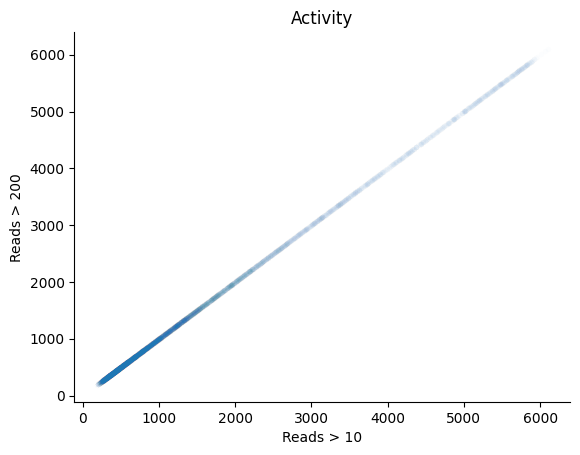

In [14]:
sns.scatterplot(data = pd.merge(all_activities, both_activities, on = "AD"),
                x = "Activity_x",
                y = "Activity_y", s = 15, alpha = 0.01)
plt.xlabel("Reads > 10")
plt.ylabel("Reads > 200")
plt.title("Activity")
sns.despine()

# Adding error

In [23]:
bc_activities = pd.read_csv("../output/testgfp1_activity_SK_by_barcode.csv")
bc_activities = bc_activities.rename(columns = {"Unnamed: 0" : "BC", 
                                                "0_y" : "AD"})
bc_bin_counts = pd.read_csv("../output/testgfp1_bins_SK_by_barcode.csv")
bc_bin_counts = bc_bin_counts.rename(columns = {"Unnamed: 0" : "BC"})
bc_bin_counts["reads"] = bc_bin_counts.iloc[:, 1:].sum(axis = 1)
bc_activity_reads = pd.merge(bc_activities, bc_bin_counts, on = "BC")
bc_activity_reads_all = bc_activity_reads.copy(deep = True)
bc_activity_reads = bc_activity_reads[bc_activity_reads["reads"] > 200]
bc_activity_reads

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...,4579.0,1697.0,357.0,1219.0,0.0,146.0,0.0,0.0,7998.0
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...,15995.0,14173.0,5279.0,3677.0,232.0,131.0,5.0,6.0,39498.0
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...,3873.0,4419.0,4126.0,589.0,1212.0,857.0,0.0,0.0,15076.0
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...,306407.0,292602.0,218496.0,145500.0,24300.0,19114.0,7411.0,5240.0,1019070.0
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,59645.0,45193.0,13561.0,3004.0,425.0,715.0,792.0,384.0,123719.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53541,CAGACAAGCTG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TCTACTGGTCAAGTCTTGTTTGCTATTGATGACTTTAGATGGTTGT...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,260.0,260.0
53543,AAACGATGAGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TATCCACCAAGAGATGATTATCATGAACAACCATATCCAGTTATGG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,474.0,474.0
53545,ACTTGAAGTTC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,CAGAAGATTGTCTTGGATCCAGATAATATTGAATTGGATGATCCAC...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,311.0,311.0
53546,ACTCCAGTCGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,CAGAAAGCTGTCTTTGCTAGATCTAGAATTAATCAATATAATGATG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,214.0,214.0


In [17]:
ad_err = bc_activity_reads[["AD","Activity"]].groupby("AD").std()
ad_err = ad_err.reset_index()
ad_err = ad_err.rename(columns = {"Activity" : "std"})
ad_err

,AD,std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,751.168229
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,NaN
2,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,NaN
3,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,2124.382413
4,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,NaN
...,...,...
5881,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGATCCATTGT...,3628.485765
5882,TTTGATTCTCCAGATGTTGCTGAATCATTTGAAACTGCTCCATTGT...,1752.721129
5883,TTTGATTGGGAACCAACTGATTCTGGTTCTCAATTTATCTTAAATT...,NaN
5884,TTTGCTGCTGGTGCTAGGAAGAGAAGGAAGATTCATGATGATGACT...,NaN


In [19]:
over_200_activities_err = pd.merge(over_200_activities, ad_err, on = "AD", how = 'left')
over_200_activities_err

,AD,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,Activity,std
0,AAACAAAGACAGAATCAGAATCAAGGTCAACAACAACCAACTTGGT...,0.176208,0.134508,0.119441,0.118305,0.124244,0.153708,0.121450,0.052136,1106.580090,751.168229
1,AAACAAAGAGATAATGAAGATAATGGTGAAGAAGATCCAACTTGGT...,0.000597,0.000335,0.031946,0.079672,0.225509,0.478372,0.169164,0.014405,1406.760337,NaN
2,AAACAAATTGATATTTATAAATATGATCCATGGGATTTGCCAAGAG...,0.246809,0.350404,0.222146,0.179075,0.000638,0.000341,0.000181,0.000405,283.106629,NaN
3,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,0.000296,0.000377,0.001111,0.011348,0.038243,0.156882,0.485088,0.306655,3456.398406,2124.382413
4,AAACAAGATTTGGAGAAATGTCATGAATTGGGTTTGTCTGATGCTG...,0.241711,0.129947,0.115391,0.102470,0.070759,0.095096,0.155612,0.089013,1307.599766,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6891,TTTGTTGCTTCTCAATTGATGTCTCAAGAAGATGGTGTTTCTGGAT...,0.656599,0.213327,0.061126,0.027296,0.000259,0.000083,0.021688,0.019622,361.103214,NaN
6892,AAGACTACTAAAGATGGTGATAATTTGCAAGATCAAGATCAGAAAT...,0.000000,0.011386,0.739734,0.038387,0.069597,0.074348,0.044482,0.022066,677.079090,NaN
6893,ATGAAGATCTTGCCAGTTGGTTCTAGATTCTGTCCAACTGATTTGG...,0.000000,0.003562,0.000000,0.000783,0.123386,0.264223,0.519165,0.088882,2368.066214,NaN
6894,GAAATGTTGGATGATAAAGAAGAACAAGAGAAAGATAGAGATAATG...,0.000000,0.005198,0.004615,0.009143,0.010590,0.025455,0.189523,0.755476,5343.920016,NaN


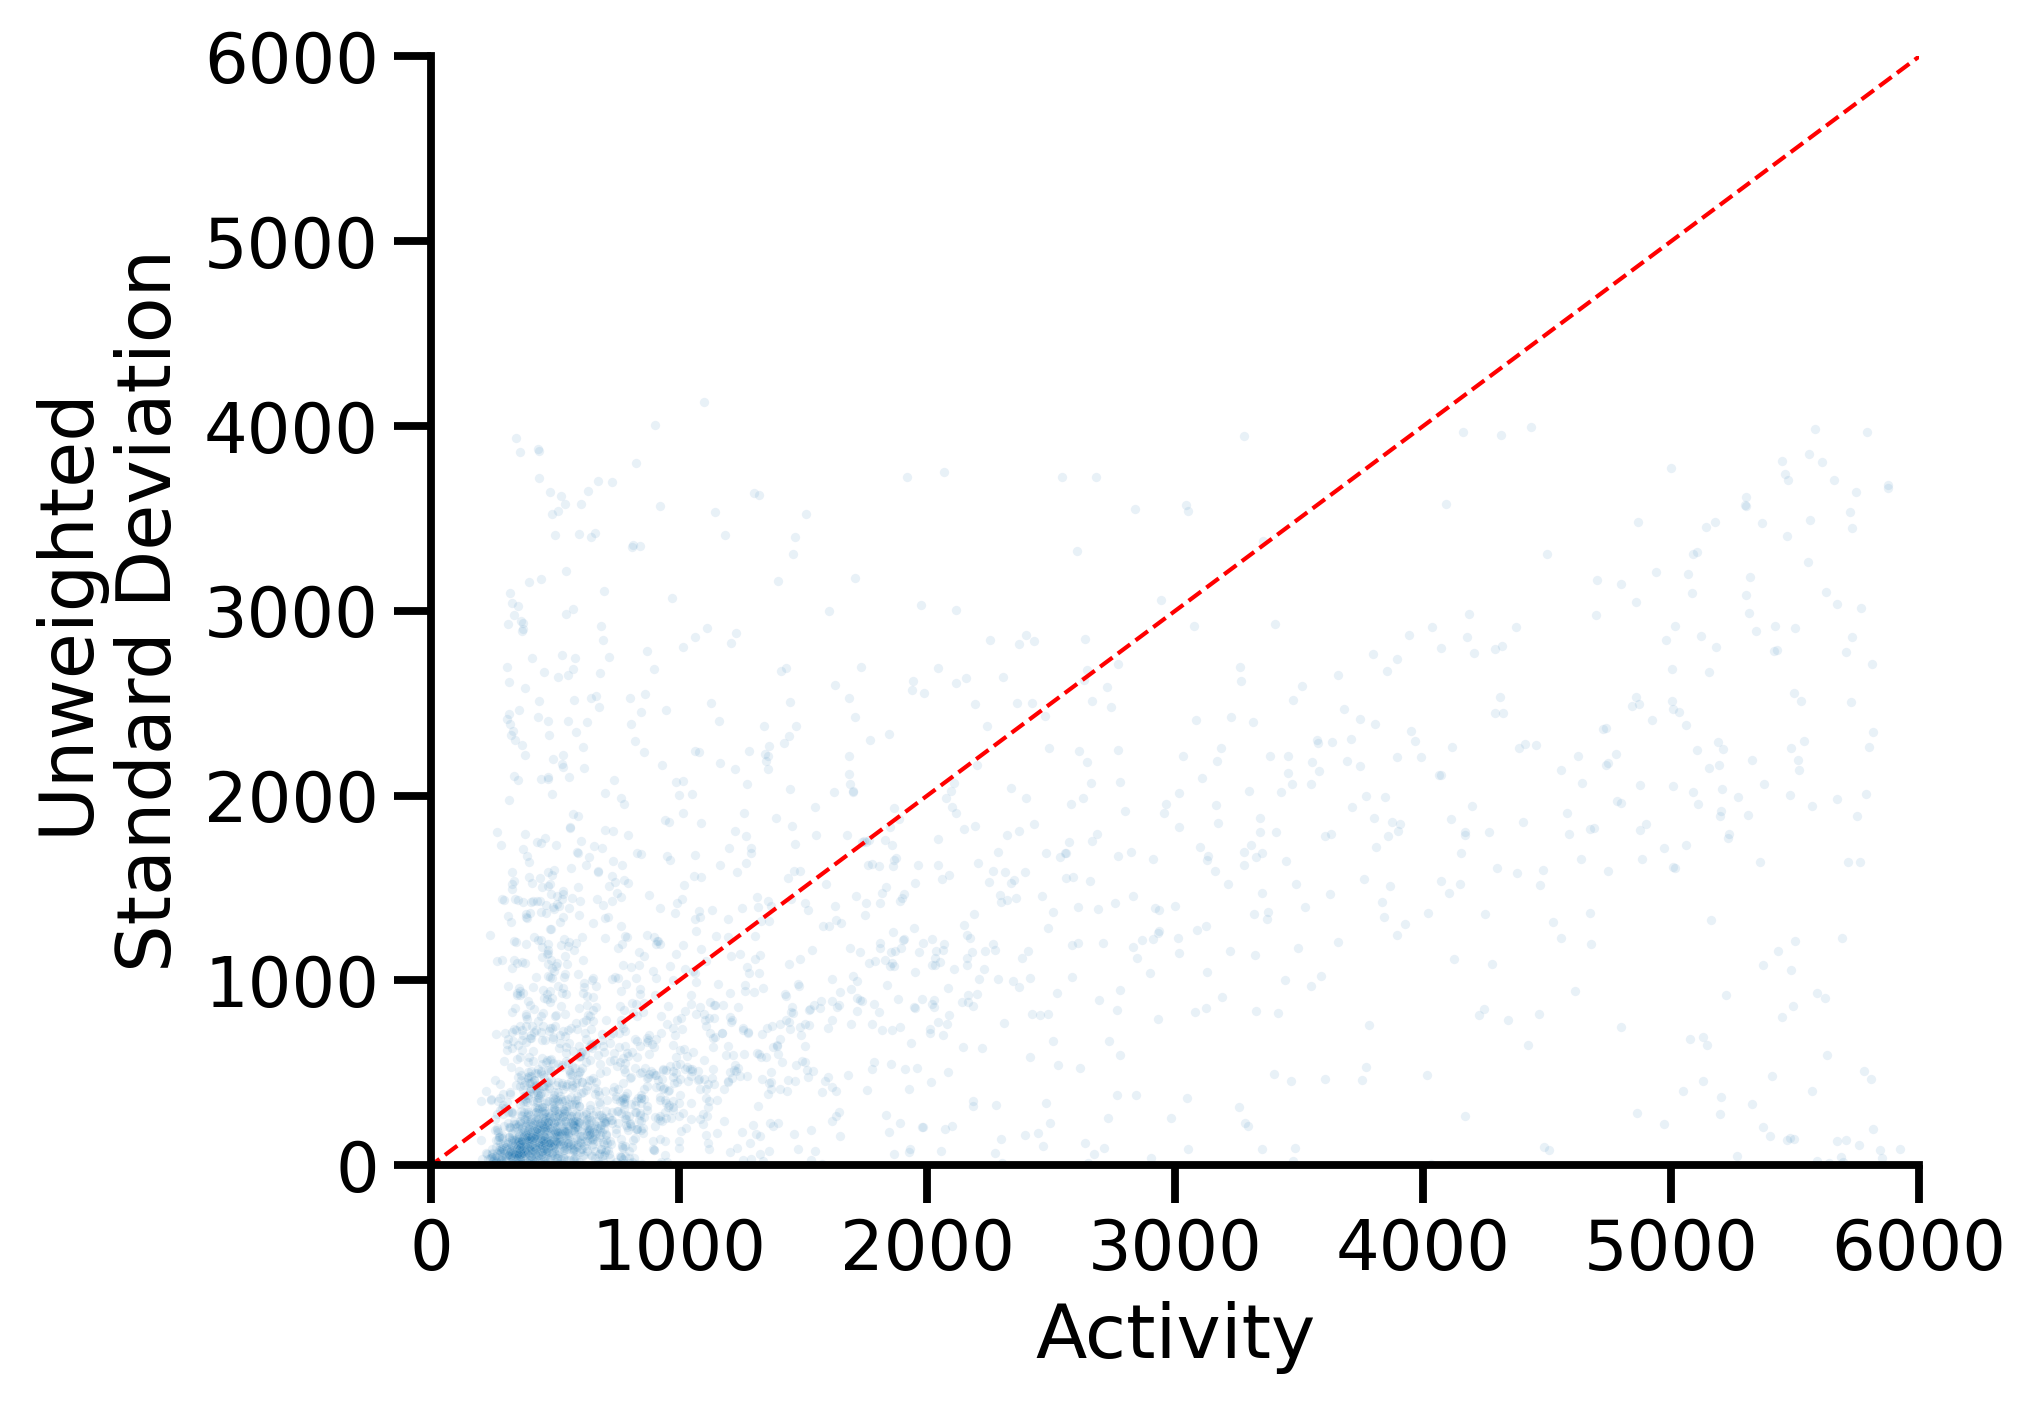

In [20]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.scatterplot(data = over_200_activities_err, x = "Activity", y = 'std', alpha = 0.1, s = 5)
xlims = plt.gca().get_xlim()
plt.plot(xlims, xlims, color='red', linestyle='--', linewidth=1)

plt.xlim(0, 6000)
plt.ylim(0, 6000)
plt.ylabel("Unweighted\nStandard Deviation")
sns.despine()
plt.show()


# ADs recovered vs BC threshold?

In [51]:
thresholds = []
unique_ADs = []

for thresh in np.arange(10, 1000, 5):
    rows_keep = bc_activity_reads_all[bc_activity_reads_all["reads"] > thresh]
    thresholds.append(thresh)
    unique_ADs.append(len(rows_keep["AD"].unique()))

threshold_AD_loss = pd.DataFrame({"threshold" : thresholds, "unique_ADs" : unique_ADs})
threshold_AD_loss

,threshold,unique_ADs
0,10,11387
1,15,10782
2,20,10217
3,25,9728
4,30,9321
...,...,...
193,975,4589
194,980,4587
195,985,4586
196,990,4583


In [59]:
threshold_AD_loss[threshold_AD_loss["threshold"] ==60]

,threshold,unique_ADs
10,60,7708


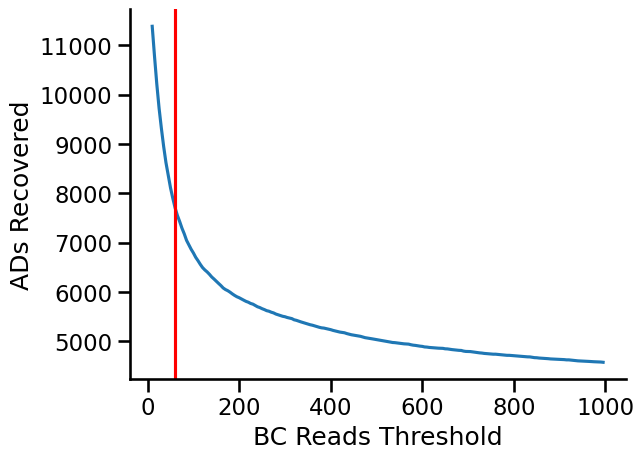

In [58]:
sns.lineplot(data = threshold_AD_loss, x = "threshold", y = "unique_ADs")
plt.xlabel("BC Reads Threshold")
plt.ylabel("ADs Recovered")
plt.axvline(60, color = 'red')
sns.despine()

In [67]:
bc_activity_reads_all[bc_activity_reads_all["AD"] == "ATGTCTTGGTTGGTTGATTCTAATAGATTTGCTACTAAGATTAAGAATGCTTCTGGTACTAGAGAAACTGAAAGAGTTAAATGGAAATCTAATCCATCTAGAGCTTGTCCAAATTGTCAA"]

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
23088,CTGATAGACCT,0.086962,0.0,0.0,0.0,0.085258,0.345852,0.481929,0.0,1799.757447,ATGTCTTGGTTGGTTGATTCTAATAGATTTGCTACTAAGATTAAGA...,2.0,0.0,0.0,0.0,2.0,10.0,13.0,0.0,27.0


In [63]:
bc_activity_reads

,BC,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,Activity,AD,0,1_y,2_y,3_y,4_y,5_y,6_y,7_y,reads
0,TCCGTCTCCTG,0.587587,0.222934,0.040448,0.134129,0.000000,0.014902,0.000000,0.000000,237.122104,CAAGCTTTGTCTTTGTGTAATAATTTGTTGGGTTCTCAGAATAGAC...,4579.0,1697.0,357.0,1219.0,0.0,146.0,0.0,0.0,7998.0
1,TCTGTTGTAAC,0.413736,0.375313,0.120563,0.081555,0.005883,0.002695,0.000110,0.000144,238.096241,TTGGAACATGGTTTGGAGAATGGTGCTGCTGCTGCTTTGGATGATA...,15995.0,14173.0,5279.0,3677.0,232.0,131.0,5.0,6.0,39498.0
2,TAGTTCGCCCT,0.268681,0.313838,0.252722,0.035037,0.082433,0.047289,0.000000,0.000000,342.651124,ACTTGGGAACCAGACTTTGATTCTGGTTCTCAATTTATCTTAAATT...,3873.0,4419.0,4126.0,589.0,1212.0,857.0,0.0,0.0,15076.0
3,TGTCCGCTGGC,0.314635,0.307595,0.198097,0.128112,0.024464,0.015612,0.006488,0.004998,335.152026,GATATCTTTGCTGCTGTTGCTCCAGCTGCTGATCCAGATGATCCTA...,306407.0,292602.0,218496.0,145500.0,24300.0,19114.0,7411.0,5240.0,1019070.0
4,GGCTTCGTGAA,0.486986,0.377752,0.097760,0.021031,0.003402,0.004643,0.005513,0.002912,244.920500,TTGGCTCATGGTTTGGCTAATGGTGCTAAAGCTATGTTGGCTGCTA...,59645.0,45193.0,13561.0,3004.0,425.0,715.0,792.0,384.0,123719.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53541,CAGACAAGCTG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TCTACTGGTCAAGTCTTGTTTGCTATTGATGACTTTAGATGGTTGT...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,260.0,260.0
53543,AAACGATGAGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,TATCCACCAAGAGATGATTATCATGAACAACCATATCCAGTTATGG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,474.0,474.0
53545,ACTTGAAGTTC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,CAGAAGATTGTCTTGGATCCAGATAATATTGAATTGGATGATCCAC...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,311.0,311.0
53546,ACTCCAGTCGA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6357.000000,CAGAAAGCTGTCTTTGCTAGATCTAGAATTAATCAATATAATGATG...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,214.0,214.0
